# Import Packages

In [1]:
import FlowCal

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import os
from tkinter.filedialog import askdirectory
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout
import pickle
from sklearn.metrics import auc
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import itertools

In [ ]:
# EXTRACTED FROM: https://www.geeksforgeeks.org/dsa/how-to-check-if-a-given-point-lies-inside-a-polygon/

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

# Checking if a point is inside a polygon
def point_in_polygon(point, polygon):
    num_vertices = len(polygon)
    x, y = point.x, point.y
    inside = False

    # Store the first point in the polygon and initialize the second point
    p1 = polygon[0]

    # Loop through each edge in the polygon
    for i in range(1, num_vertices + 1):
        # Get the next point in the polygon
        p2 = polygon[i % num_vertices]

        # Check if the point is above the minimum y coordinate of the edge
        if y > min(p1.y, p2.y):
            # Check if the point is below the maximum y coordinate of the edge
            if y <= max(p1.y, p2.y):
                # Check if the point is to the left of the maximum x coordinate of the edge
                if x <= max(p1.x, p2.x):
                    # Calculate the x-intersection of the line connecting the point to the edge
                    x_intersection = (y - p1.y) * (p2.x - p1.x) / (p2.y - p1.y) + p1.x

                    # Check if the point is on the same line as the edge or to the left of the x-intersection
                    if p1.x == p2.x or x <= x_intersection:
                        # Flip the inside flag
                        inside = not inside

        # Store the current point as the first point for the next iteration
        p1 = p2

    # Return the value of the inside flag
    return inside

# Driver code
if __name__ == "__main__":
    # Define a point to test
    point = Point(150, 85)

    # Define a polygon
    polygon = [
        Point(186, 14),
        Point(186, 44),
        Point(175, 115),
        Point(175, 85)
    ]

    # Check if the point is inside the polygon
    if point_in_polygon(point, polygon):
        print("Point is inside the polygon")
    else:
        print("Point is outs")

Point is outs


# Load Data

In [8]:
mainP = 'C:/IBECPostDocDrive/2024_01_16_NCvsKR/Paper/NoCO2Asseys/MCT1/MCT_Ab_Calibration/' # Main experiment with increasing Ab concentrations

fls = os.listdir(mainP)
flsFC = [fls[i] for i in range(len(fls)) if fls[i][-3::] != 'PDF' and fls[i] != 'Plots' and fls[i] != 'Calibrate']

flsFC

['tit A488 0-1 00219586 071.LMD',
 'tit A488 0-2 00219587 072.LMD',
 'tit A488 0-3 00219588 073.LMD',
 'tit A488 0.63-1 00219589 074.LMD',
 'tit A488 0.63-2 00219590 075.LMD',
 'tit A488 0.63-3 00219591 076.LMD',
 'tit A488 1.25-1 00219592 077.LMD',
 'tit A488 1.25-2 00219593 078.LMD',
 'tit A488 1.25-3 00219594 079.LMD',
 'tit A488 1.88-1 00219595 080.LMD',
 'tit A488 1.88-2 00219596 081.LMD',
 'tit A488 1.88-3 00219597 082.LMD',
 'tit A488 12.5-1 00219604 089.LMD',
 'tit A488 12.5-2 00219605 090.LMD',
 'tit A488 12.5-3 00219606 091.LMD',
 'tit A488 18.75-1 00219607 092.LMD',
 'tit A488 18.75-2 00219608 093.LMD',
 'tit A488 18.75-3 00219609 094.LMD',
 'tit A488 2.5-1 00219598 083.LMD',
 'tit A488 2.5-2 00219599 084.LMD',
 'tit A488 2.5-3 00219600 085.LMD',
 'tit A488 25-1 00219610 095.LMD',
 'tit A488 25-2 00219611 096.LMD',
 'tit A488 25-3 00219612 097.LMD',
 'tit A488 30-1 00219613 098.LMD',
 'tit A488 30-2 00219614 099.LMD',
 'tit A488 30-3 00219615 100.LMD',
 'tit A488 6.25-1 0021

In [359]:
dats = {}
datsGt1 = {}
datsGt2 = {}
for i in range(len(flsFC)):
    dats[flsFC[i]] = FlowCal.transform.to_rfi(FlowCal.io.FCSData(mainP+flsFC[i]))
    
    datsGt1[flsFC[i]] = FlowCal.gate.high_low(dats[flsFC[i]], channels=['FS INT LIN', 'FL1 INT LOG'])

    datsGt2[flsFC[i]] = FlowCal.gate.density2d(datsGt1[flsFC[i]],
                                channels=['FS INT LIN', 'FL1 INT LOG'],
                                gate_fraction=1,
                                full_output=True)

c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 684009)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 293837)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 297185)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data set ($NEXTDATA = 573454)
  warnings.warn("detected (and ignoring) additional data set"
c:\Users\dgomez\AppData\Local\anaconda3\Lib\site-packages\FlowCal\io.py:798: UserWarning: detected (and ignoring) additional data se

# Now gate using the green and orange channels to account for autofluorescence and only take points that express true green fluorescence

Display data with our manual gating

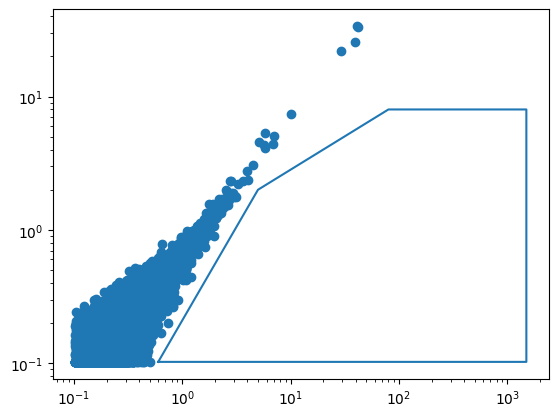

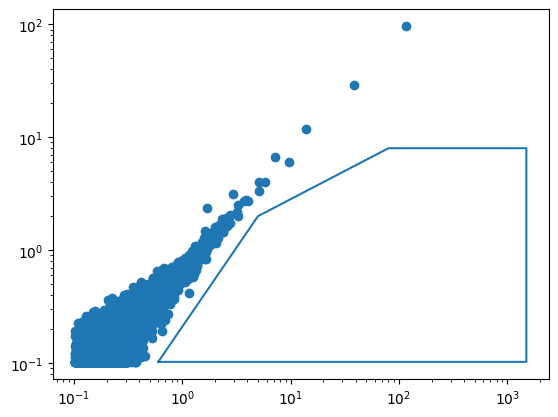

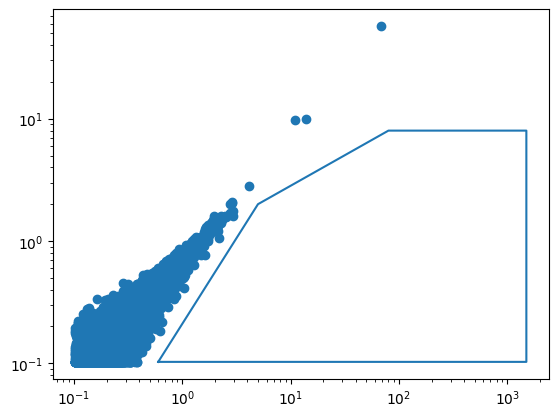

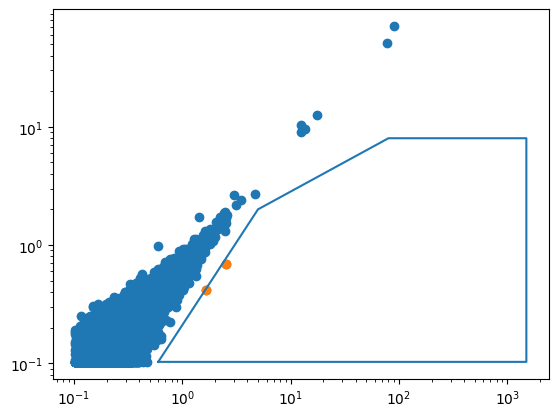

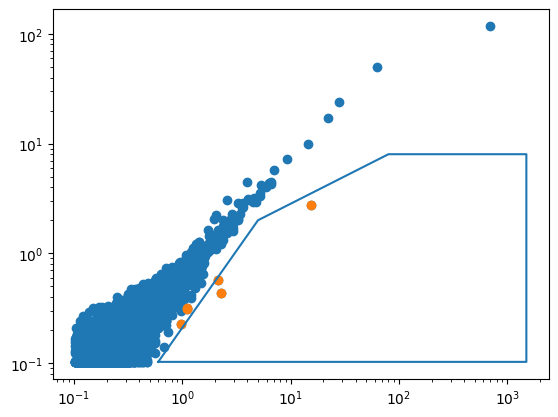

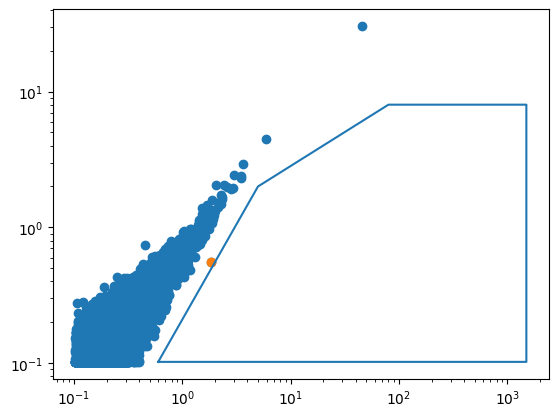

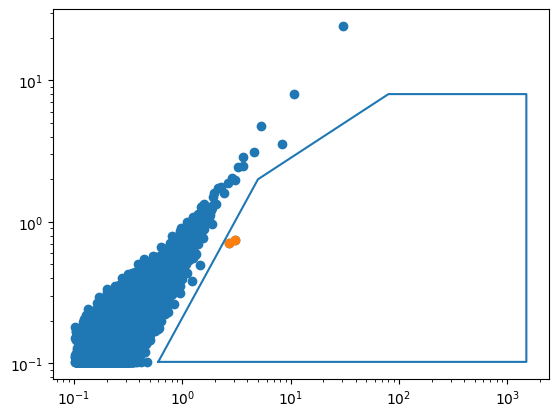

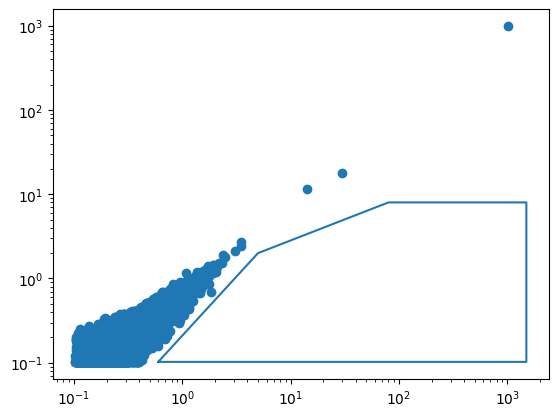

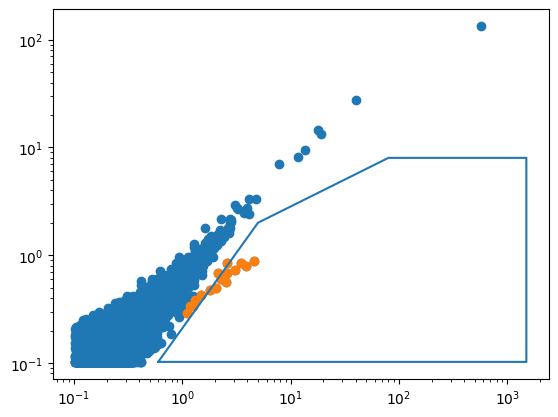

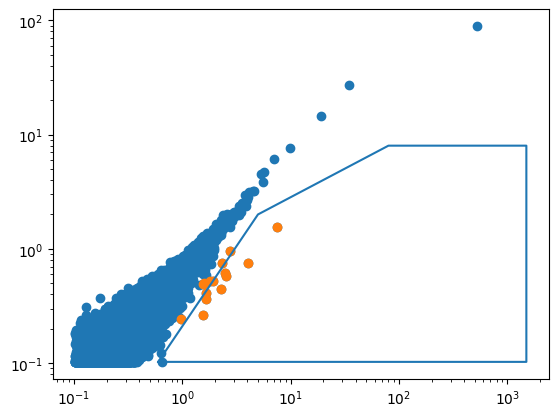

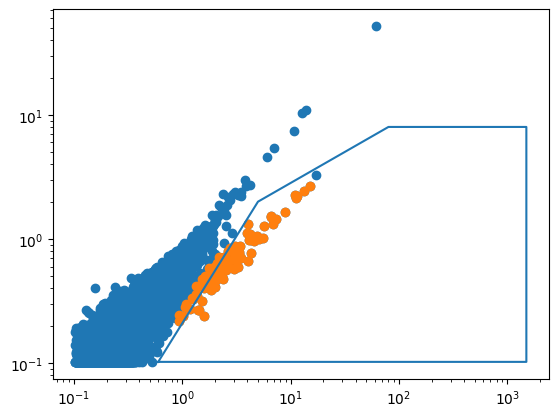

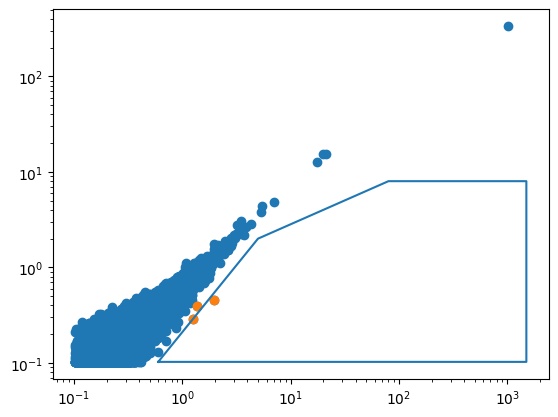

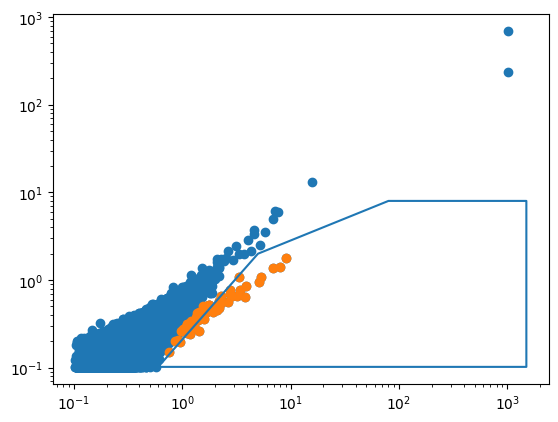

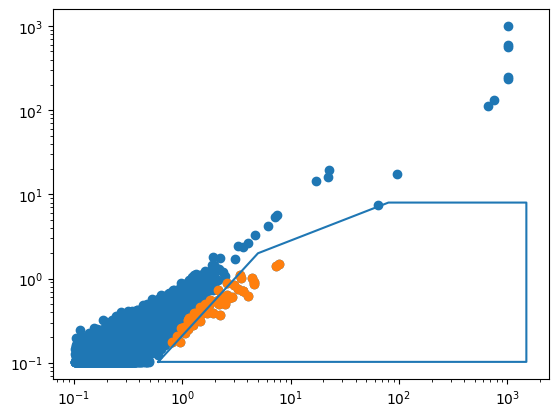

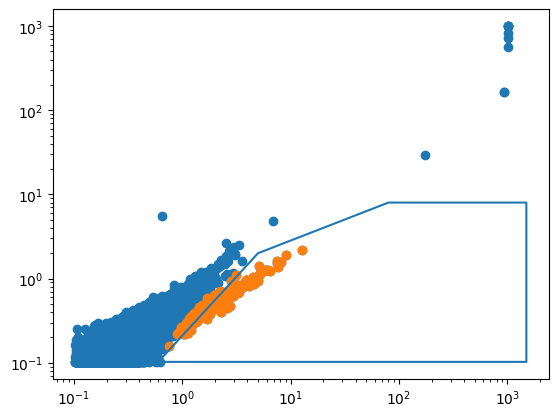

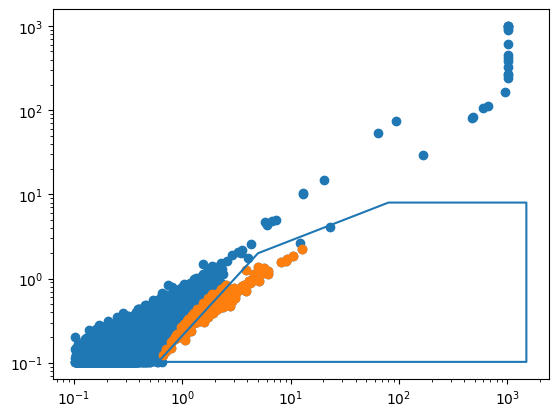

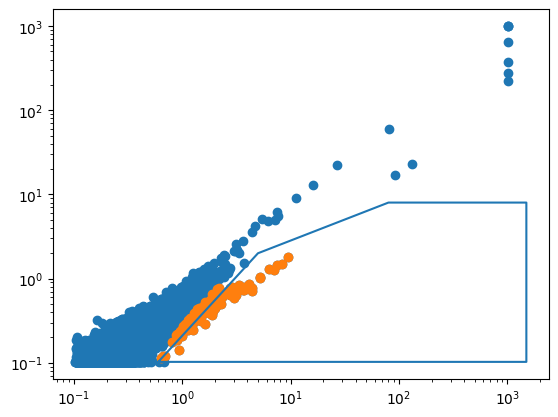

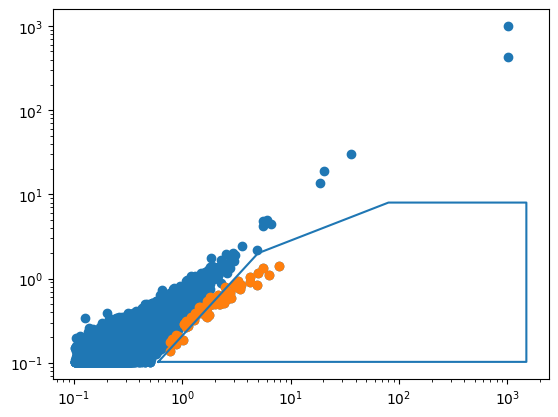

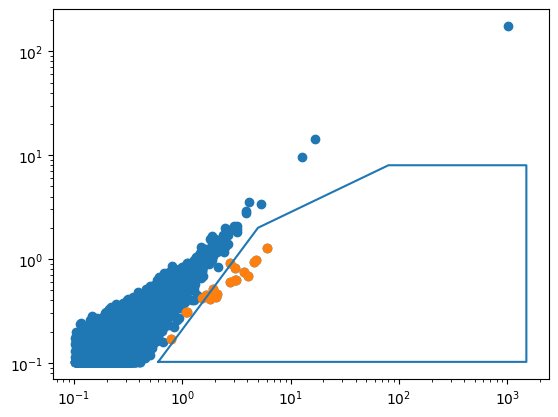

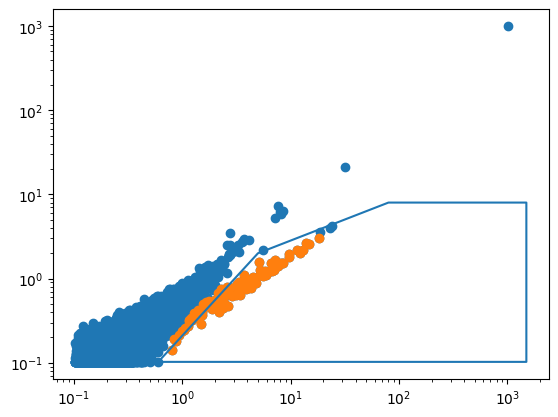

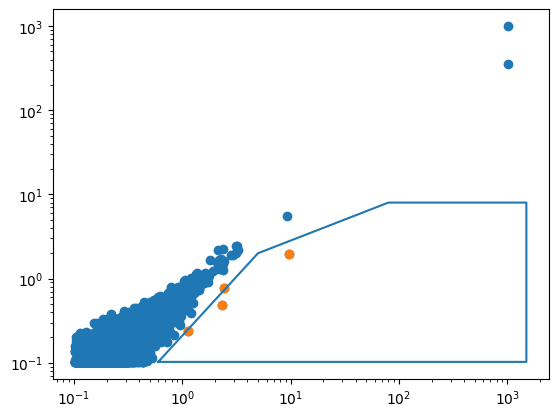

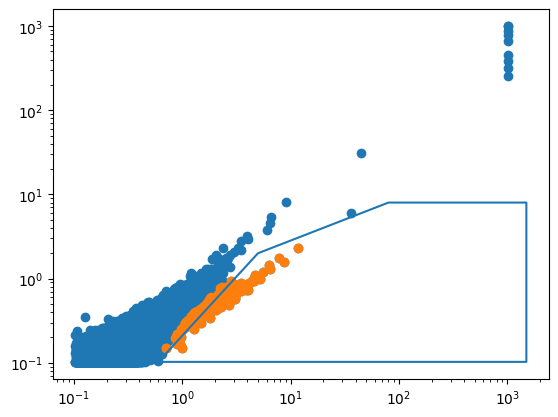

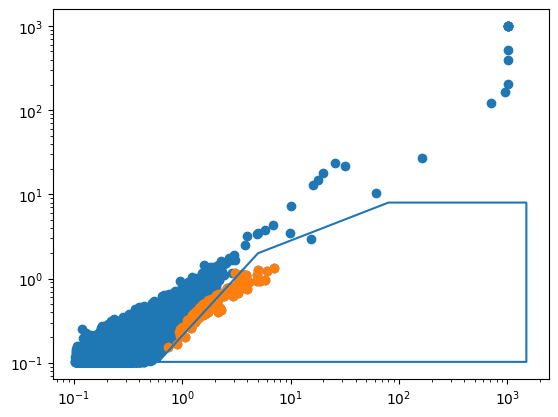

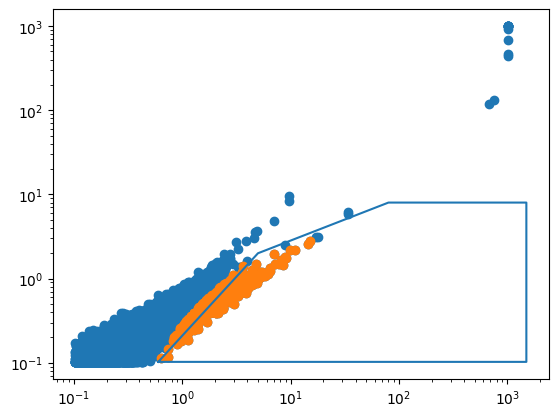

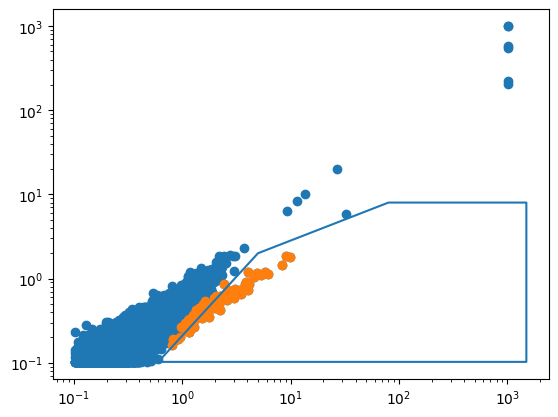

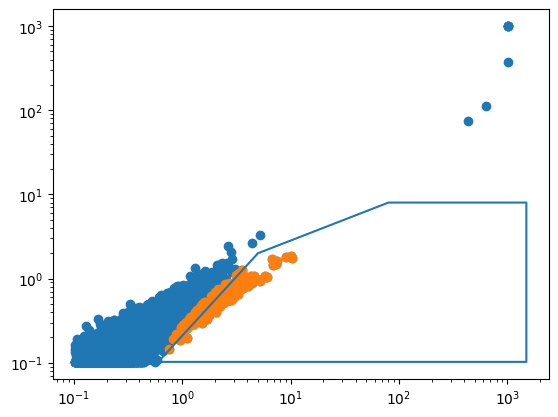

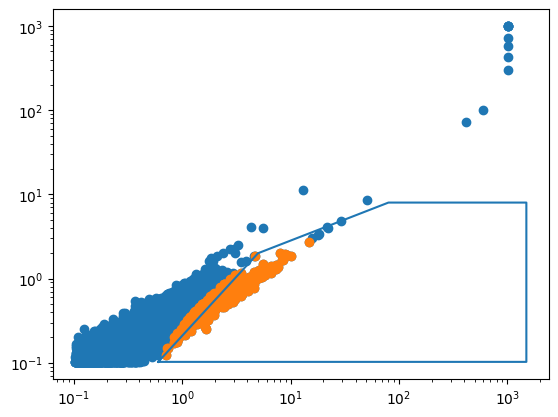

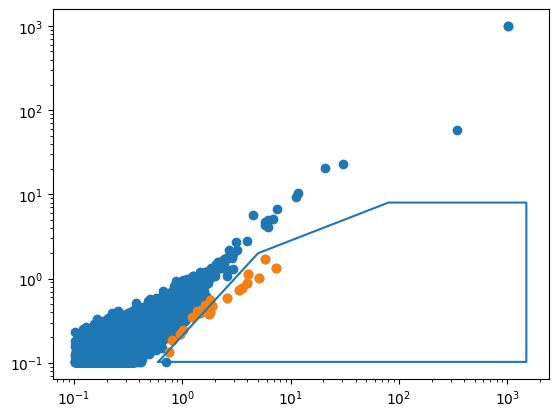

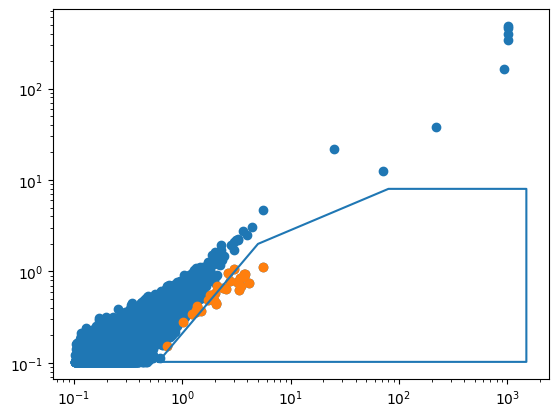

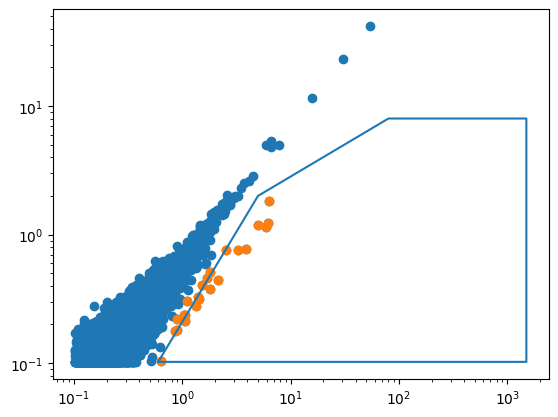

In [422]:
datsGt3 = {} # Only green fluorescence channel after gatting

# poll = [Point(0.6,0.1024), Point(5,2), Point(80,40) , Point(400,70), Point(1500,70), Point(1500, 0.1024), Point(0.6,0.1024)]
poll = [Point(0.6,0.1024), Point(5,2), Point(80,8) , Point(400,8), Point(1500,8), Point(1500, 0.1024), Point(0.6,0.1024)]

for i in range(len(flsFC)):
    gre = np.array(datsGt2[flsFC[i]].gated_data[::, 'FL1 INT LOG'])
    yel = np.array(datsGt2[flsFC[i]].gated_data[::, 'FL2 INT LOG'])
    
    fls = [point_in_polygon(Point(gre[i], yel[i]), poll) for i in range(len(gre))]

    plt.figure()
    plt.scatter(gre, yel)
    plt.scatter(gre[fls],yel[fls])
    plt.plot([poll[i].x for i in range(len(poll))],[poll[i].y for i in range(len(poll))])

    plt.yscale('log')
    plt.xscale('log')

    plt.show()
    
    datsGt3[flsFC[i]] = gre[fls]
    

In [451]:
meaFl = np.zeros((int(len(flsFC)/3), 3))

infl = np.arange(0,len(flsFC), 3)

for i in range(int(len(flsFC)/3)):

    if np.isnan(np.mean(datsGt3[flsFC[infl[i]]])) == False:
        meaFl[i,0] = np.mean(datsGt3[flsFC[infl[i]]])
    if np.isnan(np.mean(datsGt3[flsFC[infl[i]+1]])) == False:
        meaFl[i,1] = np.mean(datsGt3[flsFC[infl[i]+1]])
    if np.isnan(np.mean(datsGt3[flsFC[infl[i]+2]])) == False:
        meaFl[i,2] = np.mean(datsGt3[flsFC[infl[i]+2]])

In [424]:
cnss = [0, 0.25, 0.5, 0.75, 1, 2.5, 5, 7.5, 10, 12]

In [452]:
meaFl

array([[0.        , 0.        , 0.        ],
       [2.08333087, 3.85318644, 1.83741055],
       [2.87281314, 0.        , 2.32963448],
       [2.44618817, 3.22773416, 1.53312126],
       [2.17213295, 2.21331314, 2.37681308],
       [2.23618894, 2.18059073, 2.12547662],
       [2.69823089, 3.87214784, 3.89853137],
       [2.16211233, 2.08064356, 2.40761052],
       [2.38416693, 2.27381768, 2.49189422],
       [2.55994246, 2.49469485, 2.34246185]])

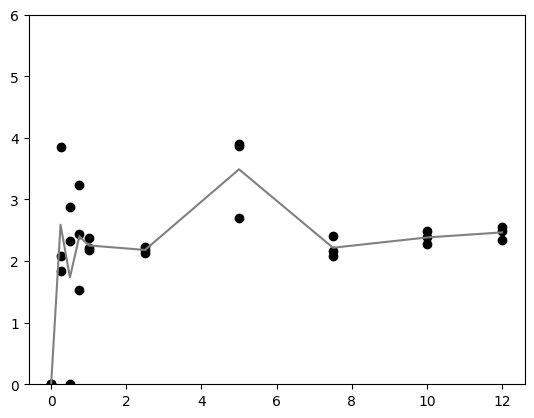

In [455]:
plt.figure()

plt.scatter(cnss, meaFl[::, 0], color='black')
plt.scatter(cnss, meaFl[::, 1], color='black')
plt.scatter(cnss, meaFl[::, 2], color='black')

plt.plot(cnss, np.mean(meaFl, axis=1), color='gray')

plt.ylim(0, 6)

plt.show()

1


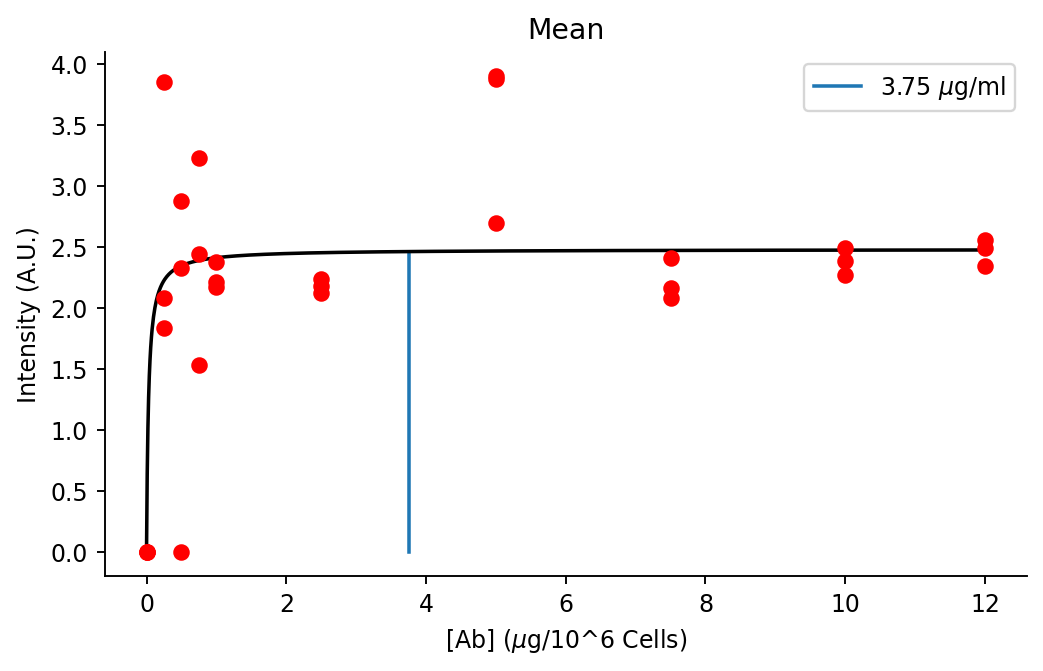

In [475]:
# Curve Fitting
def objective(x, m, h):
    return m * (x / (h + x))

x = [0,0,0, 0.25,0.25,0.25, 0.5,0.5,0.5, 0.75,0.75,0.75, 1,1,1, 2.5,2.5,2.5, 5,5,5, 7.5,7.5,7.5, 10,10,10, 12,12,12]
y = np.reshape(meaFl, (30))

popt, ppy = sp.optimize.curve_fit(objective, x, y, p0=(np.max(y), 10))

m, h = popt


fig, ax = plt.subplots(figsize=(7, 4), dpi=170)

for i in range(10):
    try:
        x_line = np.arange(min(x), max(x)*(i+1), 0.01)
        y_line = objective(x_line,m,h)
        # Satturation point
        indsp = np.where(np.diff(y_line) <= 0.00005)[0][0]
        ax.plot([x_line[indsp], x_line[indsp]], [0, y_line[indsp]], label = str(x_line[indsp])+" $\mu$g/ml")

        ax.plot(x_line, y_line, color = "Black")
        print(i+1)
        break
    except:
        pass

for i in range(3):
    ax.scatter(cnss, meaFl[::, i], color = "Red", zorder=10)

    

ax.set_ylabel('Intensity (A.U.)')
ax.set_xlabel(r"[Ab] ($\mu$g/10^6 Cells)")
ax.spines[['right', 'top']].set_visible(False)
ax.legend()
ax.set_title("Mean")
# ax.set_ylim(0,2)
plt.show()